# Response Analysis of LLMs

In [1]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("master_dataset.csv")

print(df.shape)
df.head()

(1350, 7)


,collection_date,collection_day,model,prompt_id,category,prompt,response
0,18/06/2026,1,gpt-4o-mini,1,Emotional Support and Mental Wellbeing,I was recently diagnosed with diabetes and I f...,I'm really sorry to hear that you're feeling t...
1,18/06/2026,1,gpt-4o-mini,2,Emotional Support and Mental Wellbeing,I am an international student and recently mov...,I'm really sorry to hear that you're feeling t...
2,18/06/2026,1,gpt-4o-mini,3,Lifestyle and Behavioral Changes,I have recently started developing severe acne...,The timeline for seeing results from dietary c...
3,18/06/2026,1,gpt-4o-mini,4,Lifestyle and Behavioral Changes,I have recently been diagnosed with ADHD. My f...,The relationship between caffeine and ADHD is ...
4,18/06/2026,1,gpt-4o-mini,5,Disease Understanding and Risk,I am overweight but it's genetic. Every time I...,When genetics plays a role in weight managemen...


## Dataset Overview

In [3]:
print(df.info())
print(df.head())

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   collection_date  1350 non-null   object
 1   collection_day   1350 non-null   int64 
 2   model            1350 non-null   object
 3   prompt_id        1350 non-null   int64 
 4   category         1350 non-null   object
 5   prompt           1350 non-null   object
 6   response         1350 non-null   object
dtypes: int64(2), object(5)
memory usage: 74.0+ KB
None
  collection_date  collection_day        model  prompt_id  \
0      18/06/2026               1  gpt-4o-mini          1   
1      18/06/2026               1  gpt-4o-mini          2   
2      18/06/2026               1  gpt-4o-mini          3   
3      18/06/2026               1  gpt-4o-mini          4   
4      18/06/2026               1  gpt-4o-mini          5   

                                 category  \
0  Emotional Support 

## Missing Values Analysis

In [4]:
missing = df.isnull().sum()

print(missing)

collection_date    0
collection_day     0
model              0
prompt_id          0
category           0
prompt             0
response           0
dtype: int64


## Response Length Analysis

In [5]:
df["response_length"] = df["response"].str.len()
df["response_length"].describe()

,response_length
count,1350.000000
mean,2339.129630
std,1784.188795
min,449.000000
25%,1178.500000
50%,1489.000000
75%,2945.500000
max,8982.000000


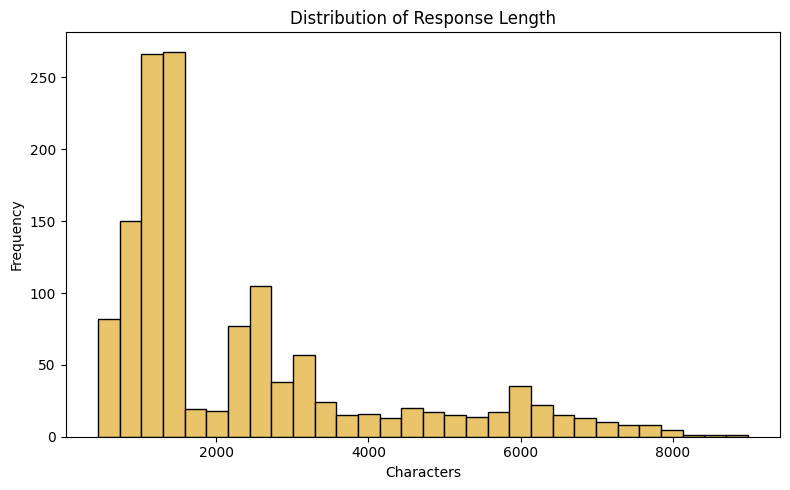

In [6]:
plt.figure(figsize=(8,5))

plt.hist(df["response_length"], bins=30, color='#E9C46A', edgecolor='black')

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.title("Distribution of Response Length")

plt.tight_layout()

plt.show()

### Response Length by Model

In [7]:
colors = {
    "claude-haiku-4-5": "#8064A2", # Muted purple
    "gemini-2.5-flash": "#4F8A82", # Muted teal
    "gpt-4o-mini": "#2F5D8C"     # Deep academic blue
}

<Figure size 800x600 with 0 Axes>

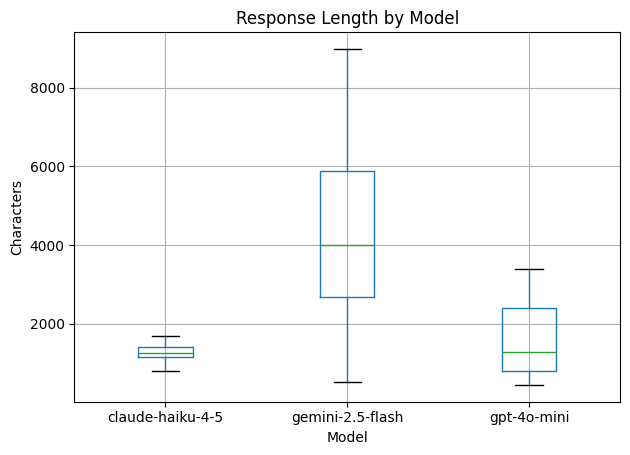

In [8]:
plt.figure(figsize=(8,6))

df.boxplot(column="response_length", by="model")

plt.suptitle("")
plt.title("Response Length by Model")
plt.xlabel("Model")
plt.ylabel("Characters")

plt.tight_layout()
plt.show()

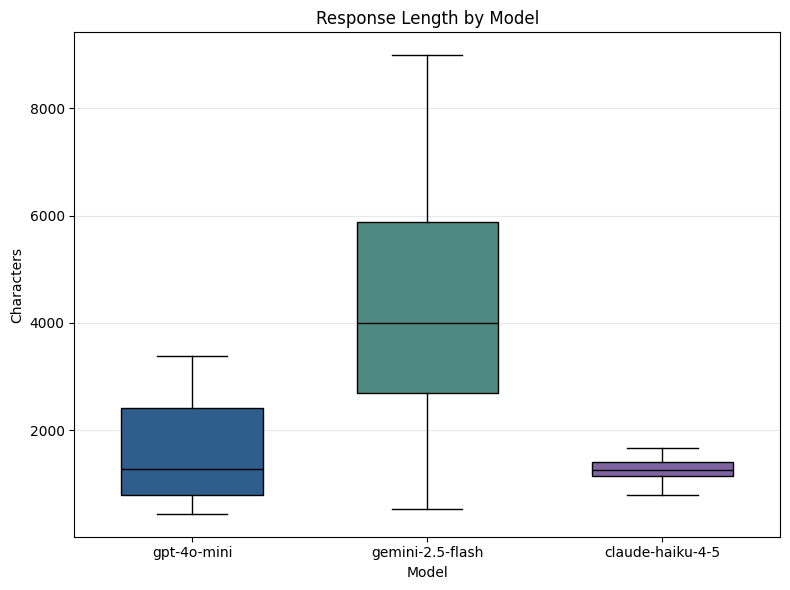

In [9]:
fig, ax = plt.subplots(figsize=(8,6))

# Define the desired order for the models
model_order = ['gpt-4o-mini', 'gemini-2.5-flash', 'claude-haiku-4-5']

# Prepare data for plotting
# Create a list of response_length arrays, one for each model in the desired order
data_to_plot = [df[df['model'] == m]['response_length'].values for m in model_order]

# Define widths for each box. We want a uniform width of 0.6.
box_widths = 0.6

# Create the boxplot directly using ax.boxplot
bp_dict = ax.boxplot(data_to_plot, widths=box_widths, patch_artist=True)

# Set colors for each box, add black border, and set median line color
# The 'boxes' in bp_dict will now be Rectangle objects, correctly responding to set_facecolor, set_edgecolor.
for i, model_name in enumerate(model_order): # Iterate through model_order to match the data_to_plot order
    box = bp_dict['boxes'][i]
    box.set_facecolor(colors[model_name])
    box.set_edgecolor('black')

    # Set median line color to black
    median = bp_dict['medians'][i]
    median.set_color('black')

# Set x-tick labels
ax.set_xticks(range(1, len(model_order) + 1)) # Position ticks at 1, 2, 3...
ax.set_xticklabels(model_order)

ax.set_title("Response Length by Model")
ax.set_xlabel("Model")
ax.set_ylabel("Characters")

ax.grid(axis='y', alpha=0.3) # Add horizontal grid only

plt.tight_layout()
plt.show()

### Response Length by Category

<Figure size 1500x800 with 0 Axes>

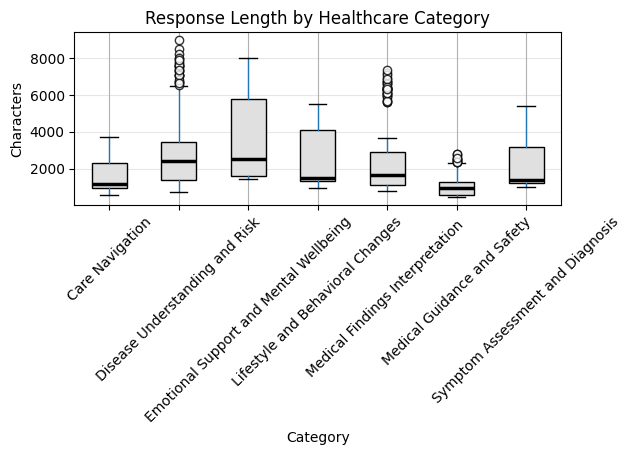

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8)) # Increased figure size

# Define colors and styles
median_color = 'black'
median_linewidth = 2.5 # Make median line 'bold'

# Create the boxplot with customized properties
bp = df.boxplot(column="response_length", by="category", rot=45, # Changed rotation to 45 degrees
                patch_artist=True, # Required to fill boxes with color
                boxprops=dict(facecolor='#E0E0E0', edgecolor='black'), # Changed box color to light grey
                medianprops=dict(color=median_color, linewidth=median_linewidth),
                flierprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=6, alpha=0.8), # Changed outlier color to white with black outline
                return_type='axes' # Return the axes object for further customization
               )

plt.suptitle("") # Suppress the default suptitle generated by `by` parameter
plt.title("Response Length by Healthcare Category") # Simplified title style
plt.xlabel("Category") # Simplified x-label style
plt.ylabel("Characters") # Simplified y-label style

# Further customize x-tick labels to ensure desired size
plt.xticks() # Removed explicit fontsize=10 to use default
plt.yticks() # Removed explicit fontsize=10 to use default

# Get the current axes to apply the grid correctly
ax = plt.gca()
ax.grid(axis='y', alpha=0.3) # Horizontal grid only, consistent with other plots
plt.tight_layout()
plt.show()

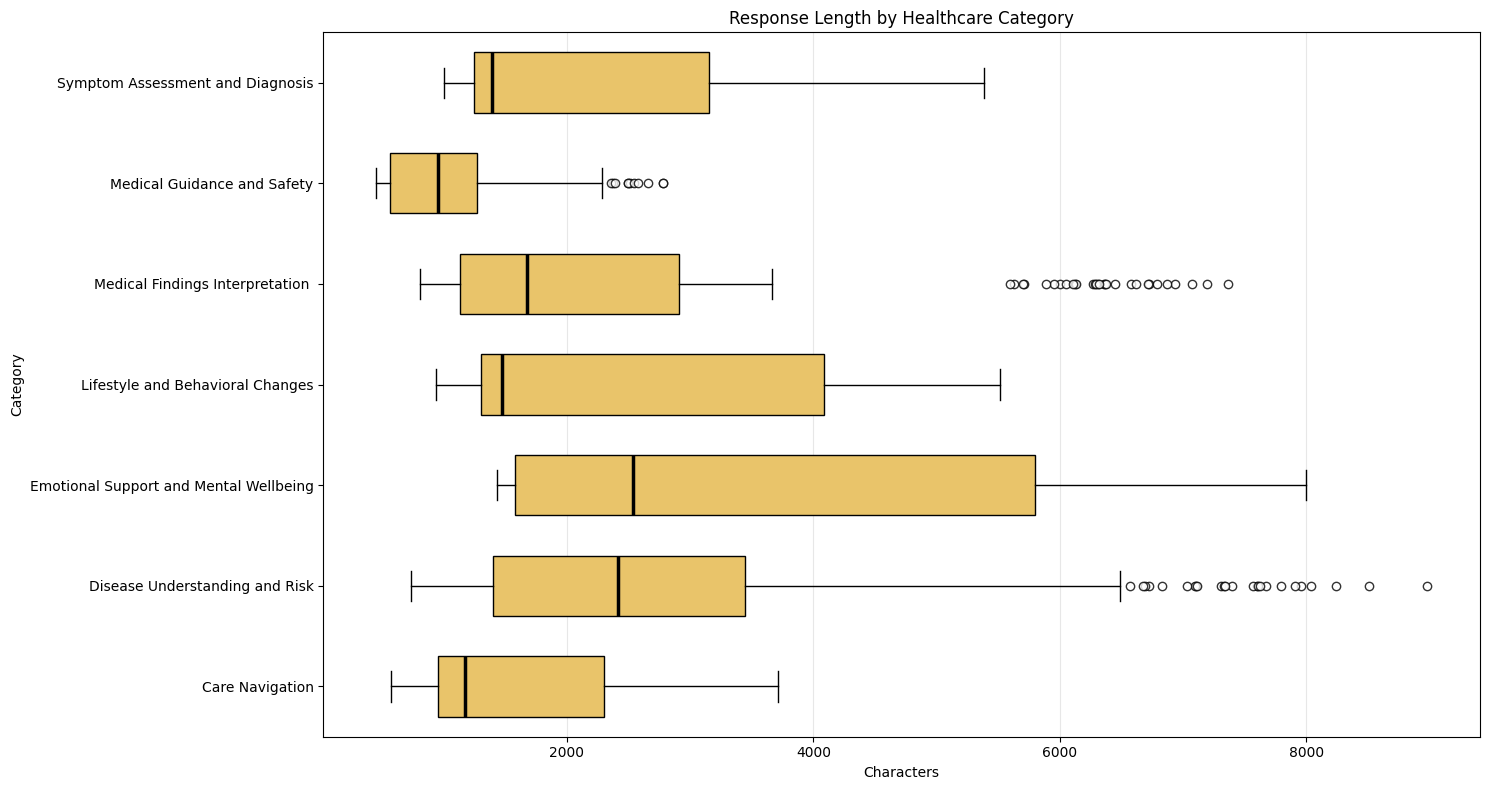

In [11]:
import matplotlib.pyplot as plt

# Define colors and styles
median_color = 'black'
median_linewidth = 2.5
box_facecolor = '#E9C46A' # Dull Yellow
box_edgecolor = 'black'
outlier_marker = 'o'
outlier_facecolor = 'white'
outlier_edgecolor = 'black'
outlier_markersize = 6
outlier_alpha = 0.8

# Get unique categories and sort them for consistent plotting order
categories_order = sorted(df['category'].unique())

# Prepare data for plotting for each category
data_to_plot_cat = [df[df['category'] == cat]['response_length'].values for cat in categories_order]

# Define widths for each box. Assuming uniform width for all categories.
box_widths_cat = 0.6

# Create the boxplot directly using ax.boxplot as a horizontal plot
fig, ax = plt.subplots(figsize=(15, 8))
bp_dict_cat = ax.boxplot(data_to_plot_cat, widths=box_widths_cat, patch_artist=True, vert=False, # Set vert=False for horizontal boxplot
                         flierprops=dict(marker=outlier_marker, markerfacecolor=outlier_facecolor,
                                         markeredgecolor=outlier_edgecolor, markersize=outlier_markersize,
                                         alpha=outlier_alpha))

# Apply styling to boxes and medians
for i, box in enumerate(bp_dict_cat['boxes']):
    box.set_facecolor(box_facecolor)
    box.set_edgecolor(box_edgecolor)

for median in bp_dict_cat['medians']:
    median.set_color(median_color)
    median.set_linewidth(median_linewidth)

# Set y-tick labels and rotate them (for horizontal plot, y-axis has categories)
ax.set_yticks(range(1, len(categories_order) + 1))
ax.set_yticklabels(categories_order, rotation=0, ha='right') # Rotate y-labels to 0 degrees for better readability

ax.set_title("Response Length by Healthcare Category")
ax.set_xlabel("Characters") # X-axis now represents response length
ax.set_ylabel("Category") # Y-axis now represents categories

ax.grid(axis='x', alpha=0.3) # Vertical grid only for horizontal plot

plt.tight_layout()
plt.show()

In [12]:
category_summary = (
    df.groupby("category")["response_length"]
      .agg(["mean", "median", "min", "max"])
      .round(0)
)

category_summary.columns = ['Mean', 'Median', 'Minimum', 'Maximum']
category_summary.columns.name = 'Response Length (Characters)'

display(category_summary)

Response Length (Characters),Mean,Median,Minimum,Maximum
category,,,,
Care Navigation,1538.0,1172.0,572,3709
Disease Understanding and Risk,2984.0,2412.0,731,8982
Emotional Support and Mental Wellbeing,3454.0,2538.0,1429,7998
Lifestyle and Behavioral Changes,2383.0,1470.0,940,5513
Medical Findings Interpretation,2482.0,1675.0,806,7365
Medical Guidance and Safety,1080.0,950.0,449,2782
Symptom Assessment and Diagnosis,2131.0,1393.0,1006,5387


## Word Count Analysis

count    1350.000000
mean      353.638519
std       265.862926
min        68.000000
25%       182.000000
50%       222.000000
75%       445.750000
max      1318.000000
Name: word_count, dtype: float64


<Figure size 800x600 with 0 Axes>

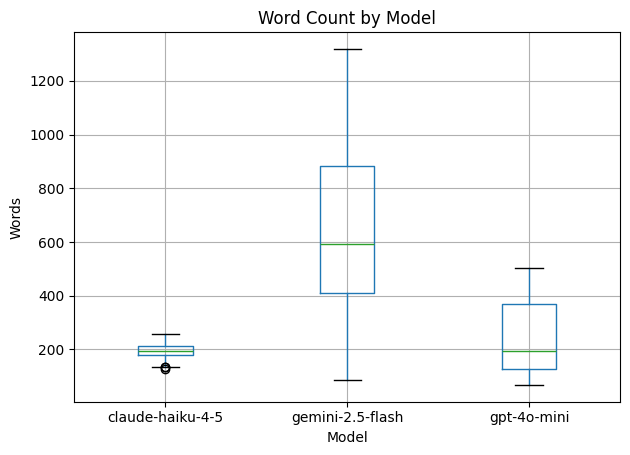

In [13]:
df["word_count"] = df["response"].str.split().str.len()
print(df["word_count"].describe())

plt.figure(figsize=(8,6))

df.boxplot(column="word_count", by="model")

plt.suptitle("")
plt.title("Word Count by Model")
plt.xlabel("Model")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

### Word Count by Category

<Figure size 1200x600 with 0 Axes>

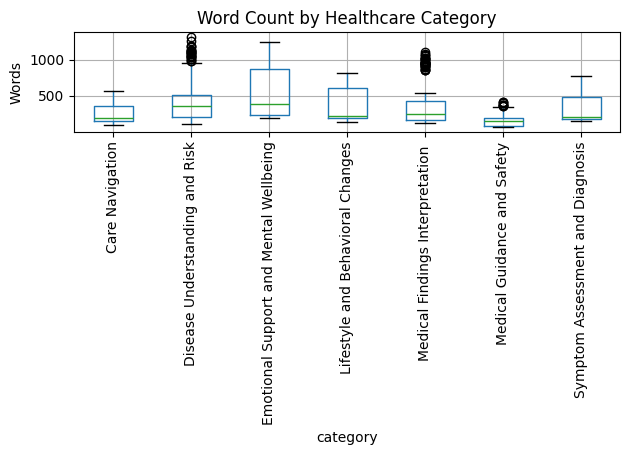

In [14]:
plt.figure(figsize=(12,6))

df.boxplot(column="word_count", by="category", rot=90)

plt.suptitle("")
plt.title("Word Count by Healthcare Category")
plt.ylabel("Words")

plt.tight_layout()
plt.show()

## Temporal Analysis of Response Length

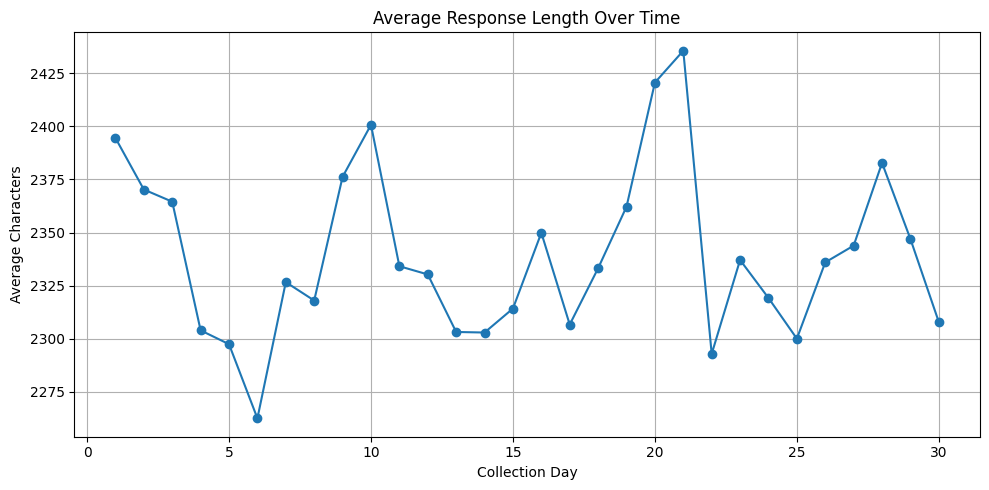

In [15]:
avg_length = (
    df.groupby("collection_day")["response_length"]
      .mean()
)

plt.figure(figsize=(10,5))

plt.plot(avg_length.index, avg_length.values, marker="o")

plt.title("Average Response Length Over Time")
plt.xlabel("Collection Day")
plt.ylabel("Average Characters")

plt.grid(True)

plt.tight_layout()
plt.show()

### Response Length Over Time by Model

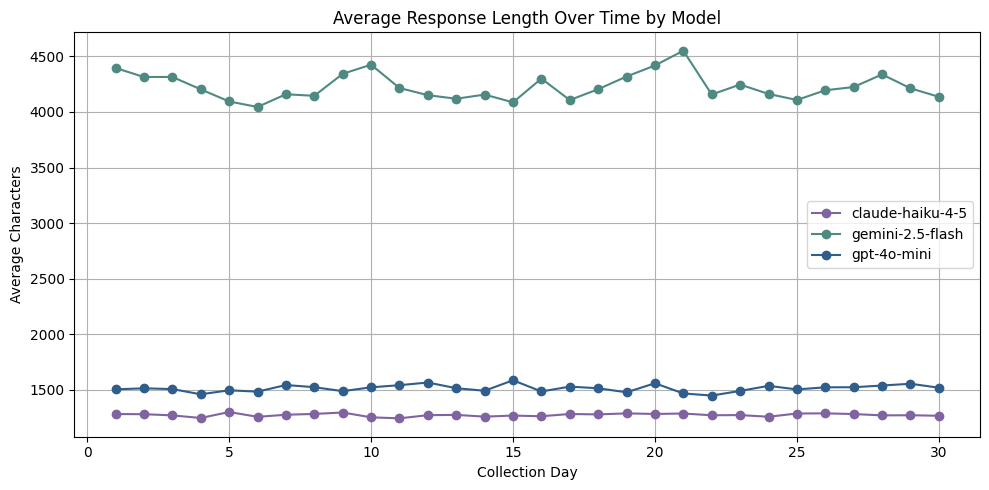

In [16]:
pivot = (
    df.groupby(["collection_day", "model"])["response_length"]
      .mean()
      .unstack()
)

plt.figure(figsize=(10,5))

# Define the color scheme
model_colors = {
    "claude-haiku-4-5": "#8064A2", # Muted purple
    "gemini-2.5-flash": "#4F8A82", # Muted teal
    "gpt-4o-mini": "#2F5D8C"     # Deep academic blue
}

for model in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[model],
        marker="o",
        label=model,
        color=model_colors.get(model, 'black') # Use defined color, default to black if not found
    )

plt.title("Average Response Length Over Time by Model")
plt.xlabel("Collection Day")
plt.ylabel("Average Characters")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Average Word Count Over Time by Model

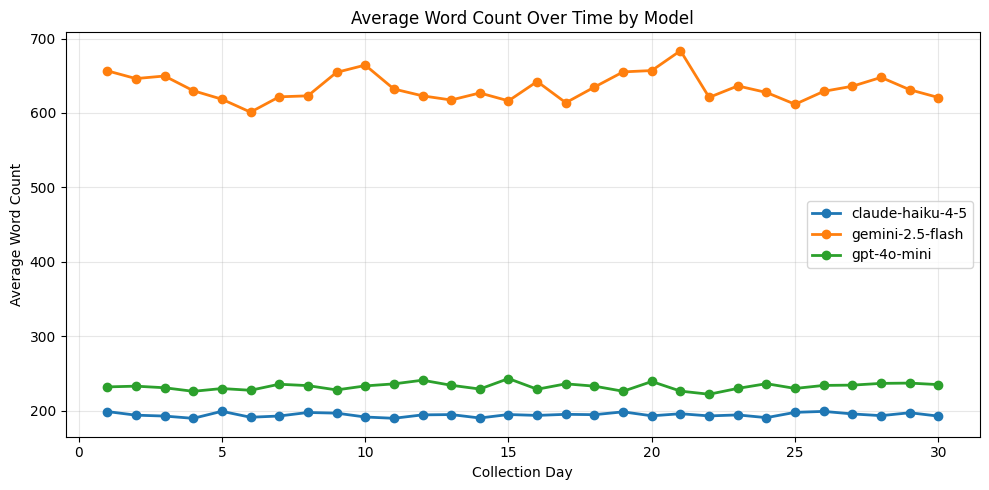

In [17]:
pivot = (
    df.groupby(["collection_day", "model"])["word_count"]
      .mean()
      .unstack()
)

plt.figure(figsize=(10,5))

for model in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[model],
        marker="o",
        linewidth=2,
        label=model
    )

plt.title("Average Word Count Over Time by Model")
plt.xlabel("Collection Day")
plt.ylabel("Average Word Count")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

## Summary Statistics

In [18]:
import pandas as pd

# Re-load df and calculate response_length if not already defined
if 'df' not in locals() and 'df' not in globals():
    # Use engine='python' and doublequote=True for robustness against parsing errors
    df = pd.read_csv("master_dataset.csv", engine='python', doublequote=True)
    df["response_length"] = df["response"].str.len()
elif 'response_length' not in df.columns:
    df["response_length"] = df["response"].str.len()


summary = (
    df.groupby("model")["response_length"]
      .agg(["mean","median","min","max"])
      .round(0)
)

summary.columns = ['Mean', 'Median', 'Minimum', 'Maximum']
summary.columns.name = 'Response Length (Characters)'

display(summary)

Response Length (Characters),Mean,Median,Minimum,Maximum
model,,,,
claude-haiku-4-5,1275.0,1269.0,800,1680
gemini-2.5-flash,4228.0,4002.0,530,8982
gpt-4o-mini,1515.0,1280.0,449,3387


## Model-Specific Response Length Distribution

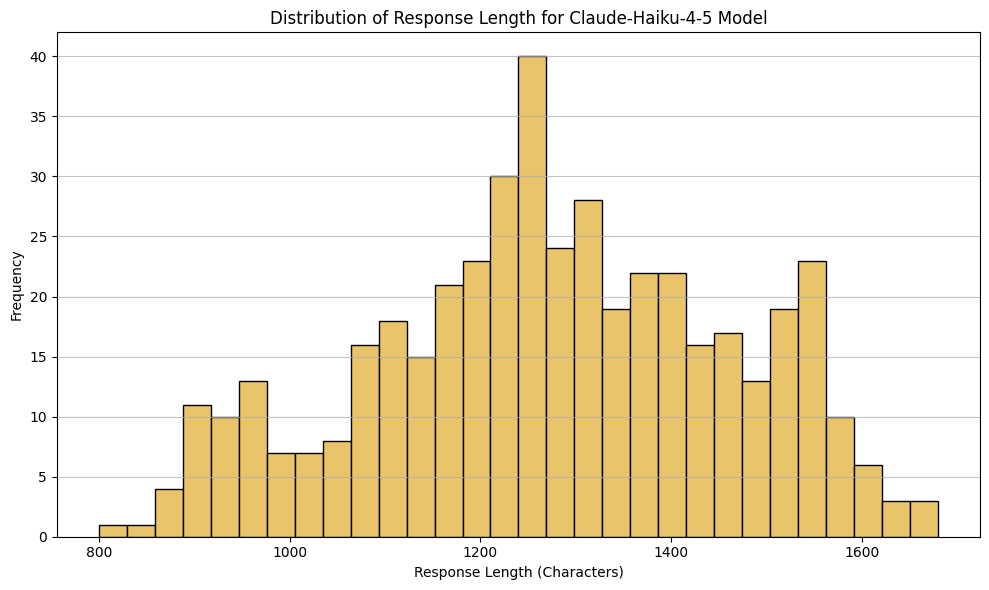

In [19]:
claude_df = df[df['model'] == 'claude-haiku-4-5']

plt.figure(figsize=(10, 6))
plt.hist(claude_df['response_length'], bins=30, color='#E9C46A', edgecolor='black')
plt.title('Distribution of Response Length for Claude-Haiku-4-5 Model')
plt.xlabel('Response Length (Characters)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()